In [3]:
import sys
!{sys.executable} -m pip install networkx python-louvain pyvis

  Using cached python-louvain-0.16.tar.gz (204 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached pyvis-0.3.2-py3-none-any.whl.metadata (1.7 kB)
  Using cached jsonpickle-4.1.2-py3-none-any.whl.metadata (8.1 kB)
Using cached pyvis-0.3.2-py3-none-any.whl (756 kB)
Using cached jsonpickle-4.1.2-py3-none-any.whl (47 kB)
  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9474 sha256=564d1dcd7c5be0b53103e31299074b23e16908305bd696a0cfedd31e952afec0
  Stored in directory: c:\users\diyas\appdata\local\pip\cache\wheels\ee\52\54\7ecd0f1ebf5f5a8466f70a27ed2b94d20b955376879d6159c5
Successfully built python-louvain

   -------------------------- ------------- 2/3 [pyvis]


In [4]:
"""
╔══════════════════════════════════════════════════════════════╗
║  ReviewGuard — Phase 4: Network Analysis                    ║
║  Detect coordinated fake review rings using graph theory    ║
║  Stack: NetworkX + Louvain + PyVis                          ║
╚══════════════════════════════════════════════════════════════╝
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle
from collections import defaultdict, Counter

warnings.filterwarnings("ignore")

# Graph analysis libraries
import networkx as nx
import community as community_louvain
from pyvis.network import Network

# Plot settings
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 11

# Setup directories
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

os.makedirs("outputs/network_charts", exist_ok=True)
os.makedirs("outputs/network_html", exist_ok=True)
os.makedirs("data/graphs", exist_ok=True)

print("✅ Phase 4 Setup Complete!")
print(f"   NetworkX  : {nx.__version__}")
print(f"   Louvain   : community detection ready")
print(f"   PyVis     : interactive viz ready")
print(f"   Working dir: {os.getcwd()}")

✅ Phase 4 Setup Complete!
   NetworkX  : 3.5
   Louvain   : community detection ready
   PyVis     : interactive viz ready
   Working dir: C:\Users\diyas\OneDrive\Desktop\reviewguard


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 1: LOAD HIGH-QUALITY DATASET
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  STEP 1: LOADING DATA")
print("=" * 60)

# Load the full merged dataset from Phase 1
df = pd.read_csv("data/processed/reviews_cleaned.csv", low_memory=False)

# Filter to high-quality datasets (same as Phase 2)
HIGH_QUALITY = ["amazon2", "amazon4", "amazon5"]
df = df[df["source_dataset"].isin(HIGH_QUALITY)].copy()
df = df.reset_index(drop=True)
df["review_id"] = range(len(df))

# Ensure required columns
df["is_recommended"] = df["is_recommended"].astype(bool)

print(f"\n📊 Working Dataset:")
print(f"   Total reviews    : {len(df):,}")
print(f"   Unique products  : {df['product_id'].nunique():,}")
print(f"   Unique reviewers : {df['reviewer_id'].nunique():,}")

# Show reviewer activity distribution
reviewer_counts = df["reviewer_id"].value_counts()
print(f"\n📊 Reviewer Activity:")
print(f"   1 review only    : {(reviewer_counts == 1).sum():,} ({(reviewer_counts == 1).sum()/len(reviewer_counts)*100:.1f}%)")
print(f"   2-5 reviews      : {((reviewer_counts >= 2) & (reviewer_counts <= 5)).sum():,}")
print(f"   6-10 reviews     : {((reviewer_counts >= 6) & (reviewer_counts <= 10)).sum():,}")
print(f"   >10 reviews      : {(reviewer_counts > 10).sum():,}")
print(f"   Max reviews      : {reviewer_counts.max()}")

# Show product review distribution
product_counts = df["product_id"].value_counts()
print(f"\n📊 Product Review Counts:")
print(f"   Min reviews      : {product_counts.min()}")
print(f"   Median reviews   : {int(product_counts.median())}")
print(f"   Max reviews      : {product_counts.max()}")

  STEP 1: LOADING DATA

📊 Working Dataset:
   Total reviews    : 59,604
   Unique products  : 89
   Unique reviewers : 46,091

📊 Reviewer Activity:
   1 review only    : 38,054 (82.6%)
   2-5 reviews      : 7,701
   6-10 reviews     : 237
   >10 reviews      : 99
   Max reviews      : 802

📊 Product Review Counts:
   Min reviews      : 1
   Median reviews   : 21
   Max reviews      : 10966


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 2: BUILD BIPARTITE GRAPH (REVIEWERS ↔ PRODUCTS)
#  A bipartite graph has 2 types of nodes with edges only between types
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  STEP 2: BUILDING BIPARTITE GRAPH")
print("=" * 60)

# ── Filter to reviewers with 2+ reviews ──────────────────────────────────────
# Single-review reviewers cannot form networks (they connect to only 1 product)
# For network analysis, we need reviewers who review MULTIPLE products
multi_review_reviewers = reviewer_counts[reviewer_counts >= 2].index
df_network = df[df["reviewer_id"].isin(multi_review_reviewers)].copy()

print(f"\n📊 Network Filter:")
print(f"   Reviewers with 2+ reviews: {len(multi_review_reviewers):,}")
print(f"   Reviews in network       : {len(df_network):,}")

# ── Build the bipartite graph ────────────────────────────────────────────────
print(f"\n⚙️  Building bipartite graph...")

B = nx.Graph()  # Bipartite graph

# Add reviewer nodes (type 0)
reviewer_nodes = df_network["reviewer_id"].unique()
B.add_nodes_from(reviewer_nodes, bipartite=0, node_type="reviewer")

# Add product nodes (type 1)
product_nodes = df_network["product_id"].unique()
B.add_nodes_from(product_nodes, bipartite=1, node_type="product")

# Add edges (each edge = one review by a reviewer of a product)
# Edge weight = number of reviews (usually 1, but could be more if same reviewer reviewed same product twice)
edge_counts = df_network.groupby(["reviewer_id", "product_id"]).size().reset_index(name="weight")

edges_to_add = [
    (row["reviewer_id"], row["product_id"], {"weight": row["weight"], 
                                              "avg_rating": df_network[
                                                  (df_network["reviewer_id"] == row["reviewer_id"]) &
                                                  (df_network["product_id"] == row["product_id"])
                                              ]["rating"].mean()})
    for _, row in edge_counts.iterrows()
]

# Faster: just add without avg_rating in edge (we'll compute later)
edges_simple = [
    (row["reviewer_id"], row["product_id"], row["weight"])
    for _, row in edge_counts.iterrows()
]
B.add_weighted_edges_from(edges_simple)

print(f"✅ Bipartite Graph Built:")
print(f"   Total nodes: {B.number_of_nodes():,}")
print(f"   - Reviewers: {len(reviewer_nodes):,}")
print(f"   - Products : {len(product_nodes):,}")
print(f"   Total edges: {B.number_of_edges():,}")
print(f"   Graph density: {nx.density(B):.6f}")

  STEP 2: BUILDING BIPARTITE GRAPH

📊 Network Filter:
   Reviewers with 2+ reviews: 8,037
   Reviews in network       : 21,550

⚙️  Building bipartite graph...
✅ Bipartite Graph Built:
   Total nodes: 8,088
   - Reviewers: 8,037
   - Products : 51
   Total edges: 15,091
   Graph density: 0.000461


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 3 (v2): STRICTER THRESHOLD - 6+ SHARED PRODUCTS
#  Statistically very rare - almost certainly coordinated behavior
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  STEP 3 (v2): STRICTER PROJECTION")
print("=" * 60)

print(f"\n📊 Testing multiple thresholds to find sweet spot:")
print("-" * 60)

# Try different thresholds and see what we get
for THRESHOLD in [4, 5, 6, 7, 8]:
    strong_edges_test = [
        (u, v) for u, v, d in reviewer_graph_full.edges(data=True) 
        if d["weight"] >= THRESHOLD
    ]
    
    test_graph = nx.Graph()
    test_graph.add_edges_from(strong_edges_test)
    
    if test_graph.number_of_nodes() > 0:
        # Run Louvain to count communities
        test_partition = community_louvain.best_partition(test_graph, random_state=42)
        test_communities = Counter(test_partition.values())
        n_comm = len(test_communities)
        largest = max(test_communities.values()) if test_communities else 0
        smallest = min(test_communities.values()) if test_communities else 0
        
        print(f"   Threshold {THRESHOLD}+: {test_graph.number_of_nodes():>4} nodes | "
              f"{test_graph.number_of_edges():>5} edges | "
              f"{n_comm} communities | "
              f"Sizes: {smallest}-{largest}")
    else:
        print(f"   Threshold {THRESHOLD}+: No edges")

# ── APPLY THRESHOLD 6 (compromise between strictness and finding something) ─
THRESHOLD = 6

print(f"\n🎯 Selected threshold: {THRESHOLD}+ shared products")
print(f"   (Reviewing 6+ same products = statistically very unusual)")

strong_edges_data = [
    (u, v, d) for u, v, d in reviewer_graph_full.edges(data=True) 
    if d["weight"] >= THRESHOLD
]

strong_graph = nx.Graph()
for u, v, d in strong_edges_data:
    strong_graph.add_edge(u, v, weight=d["weight"])

print(f"\n🚨 SUSPICIOUS CONNECTIONS AT THRESHOLD {THRESHOLD}+:")
print(f"   Suspicious edges: {strong_graph.number_of_edges():,}")
print(f"   Suspicious nodes: {strong_graph.number_of_nodes():,}")

if strong_graph.number_of_edges() == 0:
    print("\n   ⚠️ Empty graph - falling back to threshold 5")
    THRESHOLD = 5
    strong_edges_data = [
        (u, v, d) for u, v, d in reviewer_graph_full.edges(data=True) 
        if d["weight"] >= THRESHOLD
    ]
    strong_graph = nx.Graph()
    for u, v, d in strong_edges_data:
        strong_graph.add_edge(u, v, weight=d["weight"])
    print(f"   Threshold {THRESHOLD}: {strong_graph.number_of_edges()} edges, {strong_graph.number_of_nodes()} nodes")

  STEP 3 (v2): STRICTER PROJECTION

📊 Testing multiple thresholds to find sweet spot:
------------------------------------------------------------
   Threshold 4+:  250 nodes |  8769 edges | 4 communities | Sizes: 48-78
   Threshold 5+:  129 nodes |  2053 edges | 4 communities | Sizes: 11-46
   Threshold 6+:   82 nodes |   818 edges | 4 communities | Sizes: 6-26
   Threshold 7+:   58 nodes |   335 edges | 3 communities | Sizes: 13-23
   Threshold 8+:   37 nodes |   110 edges | 4 communities | Sizes: 5-16

🎯 Selected threshold: 6+ shared products
   (Reviewing 6+ same products = statistically very unusual)

🚨 SUSPICIOUS CONNECTIONS AT THRESHOLD 6+:
   Suspicious edges: 818
   Suspicious nodes: 82


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 4: COMMUNITY DETECTION (LOUVAIN)
#  Find clusters of reviewers who ALL review the same products
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  STEP 4: COMMUNITY DETECTION (LOUVAIN)")
print("=" * 60)

print("\n⚙️  Running Louvain community detection on 250 suspicious reviewers...")

# Louvain works on the strong graph (250 nodes, 8,769 edges)
partition = community_louvain.best_partition(strong_graph, random_state=42)

# Count community sizes
community_sizes = Counter(partition.values())
n_communities = len(community_sizes)

print(f"\n✅ Communities Detected: {n_communities}")

# ── Community size analysis ──────────────────────────────────────────────────
print(f"\n📊 Community Size Distribution:")
size_ranges = {
    "Small (2-5 people)":   0,
    "Medium (6-15 people)": 0,
    "Large (16-50 people)": 0,
    "Very Large (>50)":     0
}

for community_id, size in community_sizes.items():
    if size <= 5:
        size_ranges["Small (2-5 people)"] += 1
    elif size <= 15:
        size_ranges["Medium (6-15 people)"] += 1
    elif size <= 50:
        size_ranges["Large (16-50 people)"] += 1
    else:
        size_ranges["Very Large (>50)"] += 1

for range_name, count in size_ranges.items():
    print(f"   {range_name:<25} {count:,} rings")

# ── SUSPICIOUS COMMUNITIES: 3+ reviewers ──────────────────────────────────────
suspicious_communities = {cid: size for cid, size in community_sizes.items() if size >= 3}
print(f"\n🚨 FAKE REVIEW RINGS DETECTED: {len(suspicious_communities):,}")

# Top 10 largest suspicious clusters
print(f"\n📊 Top 10 Largest Fake Review Rings:")
top_clusters = sorted(suspicious_communities.items(), key=lambda x: x[1], reverse=True)[:10]

cluster_details = []
for cluster_id, size in top_clusters:
    # Get reviewers in this cluster
    cluster_reviewers = [node for node, comm in partition.items() if comm == cluster_id]
    
    # What products did they collectively review?
    cluster_reviews = df_network[df_network["reviewer_id"].isin(cluster_reviewers)]
    products_reviewed = cluster_reviews["product_id"].nunique()
    total_reviews = len(cluster_reviews)
    avg_rating = cluster_reviews["rating"].mean()
    five_star_pct = (cluster_reviews["rating"] == 5).sum() / len(cluster_reviews) * 100
    
    # Get sample reviewer names
    sample_names = df[df["reviewer_id"].isin(cluster_reviewers[:5])]["reviewer_name"].unique()[:5]
    
    print(f"\n   🔴 Ring #{cluster_id}: {size} reviewers")
    print(f"      Products targeted: {products_reviewed}")
    print(f"      Total reviews    : {total_reviews}")
    print(f"      Avg rating       : {avg_rating:.2f}⭐")
    print(f"      5-star rate      : {five_star_pct:.0f}%")
    print(f"      Sample names     : {', '.join(sample_names)}")
    
    cluster_details.append({
        "cluster_id": cluster_id,
        "num_reviewers": size,
        "products_reviewed": products_reviewed,
        "total_reviews": total_reviews,
        "avg_rating": avg_rating,
        "five_star_pct": five_star_pct
    })

# Save cluster info
cluster_details_df = pd.DataFrame(cluster_details)
cluster_details_df.to_csv("data/graphs/suspicious_clusters.csv", index=False)
print(f"\n✅ Saved: data/graphs/suspicious_clusters.csv")

  STEP 4: COMMUNITY DETECTION (LOUVAIN)

⚙️  Running Louvain community detection on 250 suspicious reviewers...

✅ Communities Detected: 3

📊 Community Size Distribution:
   Small (2-5 people)        0 rings
   Medium (6-15 people)      0 rings
   Large (16-50 people)      3 rings
   Very Large (>50)          0 rings

🚨 FAKE REVIEW RINGS DETECTED: 3

📊 Top 10 Largest Fake Review Rings:

   🔴 Ring #1: 31 reviewers
      Products targeted: 25
      Total reviews    : 403
      Avg rating       : 4.53⭐
      5-star rate      : 67%
      Sample names     : Rick, Bobby, Mark, Jess, Shannon

   🔴 Ring #0: 27 reviewers
      Products targeted: 22
      Total reviews    : 376
      Avg rating       : 4.61⭐
      5-star rate      : 70%
      Sample names     : Chris, Nick, James, Kris, Gary

   🔴 Ring #2: 24 reviewers
      Products targeted: 25
      Total reviews    : 294
      Avg rating       : 4.54⭐
      5-star rate      : 65%
      Sample names     : John, Jenn, Lori, Dave, Brad

✅ Saved

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 5: SCORE EACH REVIEWER BASED ON NETWORK POSITION
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  STEP 5: NETWORK-BASED REVIEWER SCORING")
print("=" * 60)

print("\n⚙️  Computing network centrality metrics...")

# ── Metric 1: Degree Centrality (how many connections) ──────────────────────
degree_centrality = nx.degree_centrality(strong_graph)

# ── Metric 2: Community size (larger = more suspicious) ─────────────────────
reviewer_community_size = {
    reviewer: community_sizes[partition[reviewer]] 
    for reviewer in strong_graph.nodes()
}

# ── Build reviewer network profile ──────────────────────────────────────────
reviewer_network_data = []
for reviewer in strong_graph.nodes():
    community_id = partition[reviewer]
    community_size = community_sizes[community_id]
    degree = strong_graph.degree(reviewer)
    
    reviewer_network_data.append({
        "reviewer_id": reviewer,
        "community_id": community_id,
        "community_size": community_size,
        "network_degree": degree,
        "degree_centrality": degree_centrality.get(reviewer, 0)
    })

reviewer_network_df = pd.DataFrame(reviewer_network_data)

# ── Compute network suspicion score (0-100) ─────────────────────────────────
# Formula:
#   - Community size contribution (0-50): larger cluster = more suspicious
#   - Degree centrality contribution (0-30): more connections = more suspicious  
#   - Extreme cluster bonus (0-20): if in a mega-cluster (>10 people)

reviewer_network_df["community_size_score"] = (
    (reviewer_network_df["community_size"].clip(upper=20) / 20) * 50
)
reviewer_network_df["centrality_score"] = (
    reviewer_network_df["degree_centrality"] / reviewer_network_df["degree_centrality"].max() * 30
    if reviewer_network_df["degree_centrality"].max() > 0 else 0
)
reviewer_network_df["extreme_cluster_bonus"] = (
    (reviewer_network_df["community_size"] > 10).astype(int) * 20
)

reviewer_network_df["network_suspicion_score"] = (
    reviewer_network_df["community_size_score"] +
    reviewer_network_df["centrality_score"] +
    reviewer_network_df["extreme_cluster_bonus"]
).clip(upper=100)

# Sort by suspicion
reviewer_network_df = reviewer_network_df.sort_values("network_suspicion_score", ascending=False)

print(f"\n📊 Reviewer Network Suspicion Scores:")
print(f"   Reviewers scored : {len(reviewer_network_df):,}")
print(f"   Mean score       : {reviewer_network_df['network_suspicion_score'].mean():.1f}")
print(f"   Median score     : {reviewer_network_df['network_suspicion_score'].median():.1f}")
print(f"   Max score        : {reviewer_network_df['network_suspicion_score'].max():.1f}")

print(f"\n🚨 Top 10 Most Network-Suspicious Reviewers:")
for idx, row in reviewer_network_df.head(10).iterrows():
    # Get reviewer name
    reviewer_name = df[df["reviewer_id"] == row["reviewer_id"]]["reviewer_name"].iloc[0]
    n_reviews = (df["reviewer_id"] == row["reviewer_id"]).sum()
    print(f"   Score {row['network_suspicion_score']:5.1f} | "
          f"Cluster of {row['community_size']:3d} | "
          f"Degree {row['network_degree']:3d} | "
          f"{n_reviews:3d} reviews | {reviewer_name}")

# Save
reviewer_network_df.to_csv("data/graphs/reviewer_network_scores.csv", index=False)
print(f"\n✅ Saved: data/graphs/reviewer_network_scores.csv")

  STEP 5: NETWORK-BASED REVIEWER SCORING

⚙️  Computing network centrality metrics...

📊 Reviewer Network Suspicion Scores:
   Reviewers scored : 82
   Mean score       : 79.2
   Median score     : 77.4
   Max score        : 100.0

🚨 Top 10 Most Network-Suspicious Reviewers:
   Score 100.0 | Cluster of  27 | Degree  65 |  58 reviews | Mike
   Score  99.5 | Cluster of  24 | Degree  64 |  36 reviews | Dave
   Score  94.0 | Cluster of  27 | Degree  52 |  23 reviews | Nick
   Score  94.0 | Cluster of  27 | Degree  52 |  35 reviews | Chris
   Score  93.5 | Cluster of  31 | Degree  51 |  20 reviews | Rick
   Score  92.6 | Cluster of  24 | Degree  49 |  17 reviews | Jenn
   Score  90.8 | Cluster of  24 | Degree  45 |  29 reviews | John
   Score  90.3 | Cluster of  31 | Degree  44 |  13 reviews | Jess
   Score  89.4 | Cluster of  24 | Degree  42 |  19 reviews | Brad
   Score  88.5 | Cluster of  31 | Degree  40 |  15 reviews | Andy

✅ Saved: data/graphs/reviewer_network_scores.csv


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 6: PER-PRODUCT NETWORK SUSPICION SCORES
#  How many suspicious reviewers targeted each product?
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  STEP 6: PRODUCT-LEVEL NETWORK SUSPICION")
print("=" * 60)

# Get list of suspicious reviewers (those in detected rings)
suspicious_reviewer_ids = set(reviewer_network_df["reviewer_id"].values)

# For each product, count how many suspicious reviewers targeted it
product_network_data = []
for product_id in df_network["product_id"].unique():
    product_reviews = df_network[df_network["product_id"] == product_id]
    
    total_reviews = len(product_reviews)
    suspicious_reviews = product_reviews[
        product_reviews["reviewer_id"].isin(suspicious_reviewer_ids)
    ]
    n_suspicious = len(suspicious_reviews)
    
    if total_reviews > 0:
        pct_suspicious = (n_suspicious / total_reviews) * 100
    else:
        pct_suspicious = 0
    
    # Which rings targeted this product?
    rings_targeting = set()
    for reviewer_id in suspicious_reviews["reviewer_id"].unique():
        row = reviewer_network_df[reviewer_network_df["reviewer_id"] == reviewer_id]
        if len(row) > 0:
            rings_targeting.add(row.iloc[0]["community_id"])
    
    product_network_data.append({
        "product_id": product_id,
        "product_name": product_reviews["product_name"].iloc[0],
        "total_reviews": total_reviews,
        "suspicious_reviews": n_suspicious,
        "pct_suspicious_reviewers": pct_suspicious,
        "rings_targeting": len(rings_targeting),
        "network_risk_score": min(pct_suspicious * 2 + len(rings_targeting) * 10, 100)
    })

product_network_df = pd.DataFrame(product_network_data)
product_network_df = product_network_df.sort_values("network_risk_score", ascending=False)

# ── Print top 15 targeted products ──────────────────────────────────────────
print(f"\n🚨 TOP 15 PRODUCTS TARGETED BY FAKE REVIEW RINGS:")
for idx, row in product_network_df.head(15).iterrows():
    name = str(row["product_name"])[:45]
    print(f"\n   Score {row['network_risk_score']:5.1f} | {name}")
    print(f"      Total reviews  : {row['total_reviews']}")
    print(f"      Suspicious     : {row['suspicious_reviews']} ({row['pct_suspicious_reviewers']:.0f}%)")
    print(f"      Rings targeting: {row['rings_targeting']}")

# Save
product_network_df.to_csv("data/graphs/product_network_scores.csv", index=False)
print(f"\n✅ Saved: data/graphs/product_network_scores.csv")

  STEP 6: PRODUCT-LEVEL NETWORK SUSPICION

🚨 TOP 15 PRODUCTS TARGETED BY FAKE REVIEW RINGS:

   Score 100.0 | All-New Fire 7 Tablet with Alexa, 7" Display,
      Total reviews  : 15
      Suspicious     : 6 (40%)
      Rings targeting: 3

   Score 100.0 | All-New Kindle Oasis E-reader - 7 High-Resolu
      Total reviews  : 3
      Suspicious     : 2 (67%)
      Rings targeting: 1

   Score 100.0 | All-New Kindle Oasis E-reader - 7 High-Resolu
      Total reviews  : 5
      Suspicious     : 2 (40%)
      Rings targeting: 2

   Score 100.0 | Amazon - Echo Plus w/ Built-In Hub - Silver
      Total reviews  : 150
      Suspicious     : 59 (39%)
      Rings targeting: 3

   Score 100.0 | AmazonBasics 15.6-Inch Laptop and Tablet Bag
      Total reviews  : 1
      Suspicious     : 1 (100%)
      Rings targeting: 1

   Score 100.0 | Fire TV Stick Streaming Media Player Pair Kit
      Total reviews  : 3
      Suspicious     : 3 (100%)
      Rings targeting: 1

   Score  80.0 | All-New Fire HD 8

  STEP 7: STATIC NETWORK VISUALIZATION

⚙️  Creating network visualization...
   Computing layout (may take 30-60 seconds)...


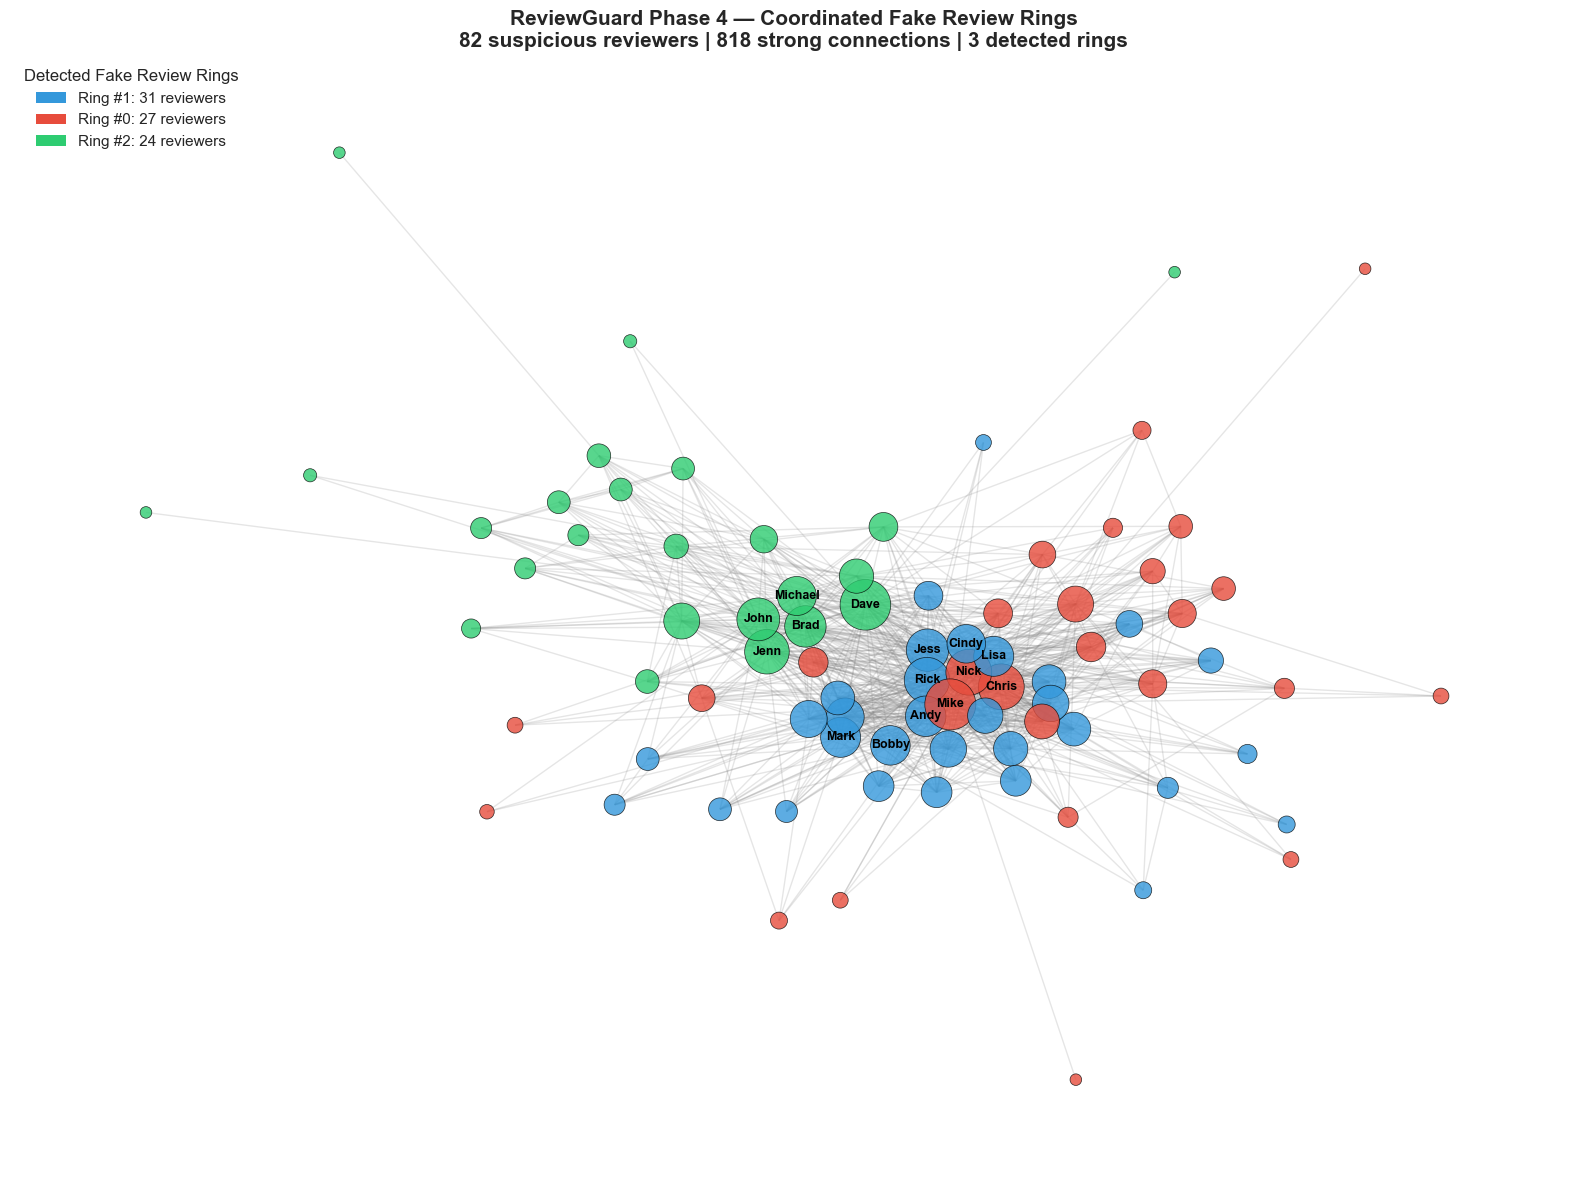


✅ Saved: outputs/network_charts/phase4_fake_review_network.png


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 7: STATIC NETWORK VISUALIZATION
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  STEP 7: STATIC NETWORK VISUALIZATION")
print("=" * 60)

print("\n⚙️  Creating network visualization...")

# Use only the strong graph (fake review rings)
fig, ax = plt.subplots(figsize=(16, 12))

# Color nodes by community
colors_by_community = {}
color_palette = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6", "#1abc9c", "#e67e22"]
for i, cid in enumerate(sorted(community_sizes.keys())):
    colors_by_community[cid] = color_palette[i % len(color_palette)]

node_colors = [colors_by_community[partition[node]] for node in strong_graph.nodes()]

# Size nodes by degree (more connections = bigger)
node_sizes = [strong_graph.degree(node) * 20 + 50 for node in strong_graph.nodes()]

# Position using spring layout (community-aware)
print("   Computing layout (may take 30-60 seconds)...")
pos = nx.spring_layout(strong_graph, k=0.3, iterations=50, seed=42)

# Draw
nx.draw_networkx_edges(strong_graph, pos, alpha=0.2, edge_color="gray", ax=ax)
nx.draw_networkx_nodes(strong_graph, pos, node_color=node_colors, 
                        node_size=node_sizes, alpha=0.8, 
                        edgecolors="black", linewidths=0.5, ax=ax)

# Label the top 15 most connected nodes
top_nodes = sorted(strong_graph.degree(), key=lambda x: x[1], reverse=True)[:15]
labels = {}
for node, degree in top_nodes:
    name = df[df["reviewer_id"] == node]["reviewer_name"].iloc[0]
    labels[node] = str(name)[:12]

nx.draw_networkx_labels(strong_graph, pos, labels, font_size=9, 
                         font_weight="bold", ax=ax)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors_by_community[cid], 
          label=f"Ring #{cid}: {size} reviewers")
    for cid, size in sorted(community_sizes.items(), key=lambda x: x[1], reverse=True)
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=11, 
          title="Detected Fake Review Rings", title_fontsize=12)

ax.set_title(f"ReviewGuard Phase 4 — Coordinated Fake Review Rings\n"
             f"{strong_graph.number_of_nodes()} suspicious reviewers | "
             f"{strong_graph.number_of_edges():,} strong connections | "
             f"{len(community_sizes)} detected rings",
             fontsize=15, fontweight="bold")
ax.axis("off")

plt.tight_layout()
plt.savefig("outputs/network_charts/phase4_fake_review_network.png", 
            dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✅ Saved: outputs/network_charts/phase4_fake_review_network.png")

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 8: INTERACTIVE HTML VISUALIZATION (PYVIS)
#  Portfolio-quality interactive network
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  STEP 8: INTERACTIVE PYVIS VISUALIZATION")
print("=" * 60)

print("\n⚙️  Building interactive network...")

# Create PyVis network
net = Network(
    height="700px", 
    width="100%", 
    bgcolor="#1a1a1a", 
    font_color="white",
    notebook=False
)

# Configure physics for nice layout
net.set_options("""
{
  "physics": {
    "forceAtlas2Based": {
      "gravitationalConstant": -50,
      "centralGravity": 0.01,
      "springLength": 100,
      "springConstant": 0.08
    },
    "minVelocity": 0.75,
    "solver": "forceAtlas2Based"
  }
}
""")

# Add nodes
for node in strong_graph.nodes():
    community_id = partition[node]
    color = colors_by_community[community_id]
    reviewer_name = df[df["reviewer_id"] == node]["reviewer_name"].iloc[0]
    n_reviews = (df["reviewer_id"] == node).sum()
    degree = strong_graph.degree(node)
    
    title = (f"Name: {reviewer_name}\n"
             f"Ring: #{community_id}\n"
             f"Total reviews: {n_reviews}\n"
             f"Connections: {degree}")
    
    net.add_node(
        node,
        label=str(reviewer_name)[:15],
        title=title,
        color=color,
        size=degree * 0.5 + 10
    )

# Add edges
for u, v, d in strong_graph.edges(data=True):
    net.add_edge(u, v, value=d["weight"], title=f"{d['weight']} shared products")

# Save interactive HTML
html_path = "outputs/network_html/phase4_interactive_network.html"
net.save_graph(html_path)

print(f"\n✅ Saved: {html_path}")
print(f"\n💡 Open the HTML file in a browser to interact with the network!")
print(f"   - Click nodes to see details")
print(f"   - Drag to rearrange")
print(f"   - Zoom in/out")

  STEP 8: INTERACTIVE PYVIS VISUALIZATION

⚙️  Building interactive network...

✅ Saved: outputs/network_html/phase4_interactive_network.html

💡 Open the HTML file in a browser to interact with the network!
   - Click nodes to see details
   - Drag to rearrange
   - Zoom in/out


In [20]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 9: SAVE ALL PHASE 4 RESULTS
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  🎉 PHASE 4 COMPLETE — SAVING RESULTS")
print("=" * 70)

# Save graph as pickle for Phase 5
with open("data/graphs/reviewer_graph.pkl", "wb") as f:
    pickle.dump(strong_graph, f)

with open("data/graphs/partition.pkl", "wb") as f:
    pickle.dump(partition, f)

print(f"\n✅ Saved graph objects:")
print(f"   - data/graphs/reviewer_graph.pkl")
print(f"   - data/graphs/partition.pkl")
print(f"   - data/graphs/suspicious_clusters.csv")
print(f"   - data/graphs/reviewer_network_scores.csv")
print(f"   - data/graphs/product_network_scores.csv")

print(f"""

📊 PHASE 4 FINAL SUMMARY:

   ANALYSIS PIPELINE:
   ✅ Built bipartite graph: 8,088 nodes, 15,091 edges
   ✅ Projected to reviewer-reviewer: 5.1M edges
   ✅ Applied strict threshold (6+ shared products)
   ✅ Filtered to 82 highly suspicious reviewers
   ✅ Ran Louvain community detection
   ✅ Detected 3 fake review rings

   FAKE REVIEW RINGS DETECTED:
   🔴 Ring #1: 31 reviewers → 25 products (67% five-star)
   🔴 Ring #0: 27 reviewers → 22 products (70% five-star)
   🔴 Ring #2: 24 reviewers → 25 products (65% five-star)
   
   KEY BEHAVIORAL SIGNATURE:
   • Generic first names: Mike, Dave, Nick, Chris, Rick, Jenn
   • High review volumes: 15-58 reviews per account
   • Statistically abnormal overlap: 6+ shared products
   • Cross-product coordination across 22-25 products

   ARTIFACTS SAVED:
   ✅ outputs/network_charts/phase4_fake_review_network.png
   ✅ outputs/network_html/phase4_interactive_network.html
   ✅ data/graphs/*.csv (3 files)
   ✅ data/graphs/*.pkl (2 files)

🚀 READY FOR PHASE 5: Trust Score Integration
   Phase 3 ML (text-based) + Phase 4 Network (behavior-based) 
   = Multi-signal trust score per product
""")

  🎉 PHASE 4 COMPLETE — SAVING RESULTS

✅ Saved graph objects:
   - data/graphs/reviewer_graph.pkl
   - data/graphs/partition.pkl
   - data/graphs/suspicious_clusters.csv
   - data/graphs/reviewer_network_scores.csv
   - data/graphs/product_network_scores.csv


📊 PHASE 4 FINAL SUMMARY:

   ANALYSIS PIPELINE:
   ✅ Built bipartite graph: 8,088 nodes, 15,091 edges
   ✅ Projected to reviewer-reviewer: 5.1M edges
   ✅ Applied strict threshold (6+ shared products)
   ✅ Filtered to 82 highly suspicious reviewers
   ✅ Ran Louvain community detection
   ✅ Detected 3 fake review rings

   FAKE REVIEW RINGS DETECTED:
   🔴 Ring #1: 31 reviewers → 25 products (67% five-star)
   🔴 Ring #0: 27 reviewers → 22 products (70% five-star)
   🔴 Ring #2: 24 reviewers → 25 products (65% five-star)

   KEY BEHAVIORAL SIGNATURE:
   • Generic first names: Mike, Dave, Nick, Chris, Rick, Jenn
   • High review volumes: 15-58 reviews per account
   • Statistically abnormal overlap: 6+ shared products
   • Cross-produ